# USDOT Intersection Safety Challenge — Stage-1B
## Dataset Structure Exploration: VALIDATION Subset

**Goal:** Lightweight, manual inspection of the validation dataset — understand structure, file types, schema, and timestamp alignment.  
**No LiDAR / video processing. No large file loads.**

---
## 0. Setup & Config

> **Strategy:** Download the zip directly into Colab's `/content/` (no Drive needed).  
> Then do a **selective unzip** — skip `.pcap` and video files so we only extract  
> the lightweight metadata/CSV/annotation files needed for structural exploration.

In [1]:
# ── Step 1: Download the dataset zip into /content/ ───────────────────────
# ~30 GB zip, but we will NOT unzip large files (pcap/video).
# Colab's /content/ has ~100 GB ephemeral disk — plenty for selective extraction.

import os, sys
from pathlib import Path

DOWNLOAD_URL  = 'https://data.transportation.gov/download/j58q-ymi4/application%2Fx-zip-compressed'
ZIP_PATH      = '/content/isc_stage1b.zip'
EXTRACT_ROOT  = '/content/isc_stage1b'

# Only download if not already present (allows re-running without re-downloading)
if not Path(ZIP_PATH).exists():
    print('Downloading dataset (~30 GB) … this will take several minutes.')
    os.system(f'wget -q --show-progress -O "{ZIP_PATH}" "{DOWNLOAD_URL}"')
    print(f'Download complete: {ZIP_PATH}')
else:
    size_gb = Path(ZIP_PATH).stat().st_size / 1e9
    print(f'Zip already present ({size_gb:.2f} GB) — skipping download.')

Download complete: /content/isc_stage1b.zip


In [2]:
# ── Step 2: Peek inside the zip — list all entries WITHOUT extracting ──────
# This tells us the internal folder structure before we touch disk.

import zipfile

print(f'Opening zip: {ZIP_PATH}')
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    all_entries = zf.namelist()

print(f'Total entries in zip : {len(all_entries):,}')
print()

# Show the top-level structure (unique first-path-components)
top_level = sorted(set(e.split('/')[0] for e in all_entries if e.strip()))
print(f'Top-level entries ({len(top_level)}):')
for t in top_level[:30]:
    print(f'  {t}')
if len(top_level) > 30:
    print(f'  ... ({len(top_level) - 30} more)')

Opening zip: /content/isc_stage1b.zip
Total entries in zip : 1,466

Top-level entries (42):
  Run_1003
  Run_1023
  Run_1027
  Run_1078
  Run_108
  Run_1169
  Run_1214
  Run_1228
  Run_1229
  Run_1253
  Run_1256
  Run_1280
  Run_1290
  Run_179
  Run_186
  Run_214
  Run_291
  Run_310
  Run_315
  Run_316
  Run_359
  Run_363
  Run_410
  Run_423
  Run_448
  Run_469
  Run_478
  Run_48
  Run_486
  Run_55
  ... (12 more)


In [3]:
# ── Step 3: Identify the validation subset path inside the zip ────────────
# The zip may contain multiple splits (train/validation/test).
# We locate the "validation" folder automatically.

validation_prefix = None
for entry in all_entries:
    parts = [p for p in entry.lower().split('/') if p]
    if 'validation' in parts or 'val' in parts:
        # Keep the original-case prefix up to and including the validation folder
        orig_parts = entry.split('/')
        for i, p in enumerate(orig_parts):
            if p.lower() in ('validation', 'val'):
                validation_prefix = '/'.join(orig_parts[:i+1]) + '/'
                break
    if validation_prefix:
        break

if validation_prefix is None:
    # Fallback: maybe the whole zip IS the validation set
    validation_prefix = ''
    print('No explicit validation/ folder found — treating entire zip as the dataset.')
else:
    print(f'Validation prefix detected: "{validation_prefix}"')

# Count validation entries
val_entries = [e for e in all_entries if e.startswith(validation_prefix) and not e.endswith('/')]
print(f'Validation file entries  : {len(val_entries):,}')

No explicit validation/ folder found — treating entire zip as the dataset.
Validation file entries  : 1,425


In [4]:
# ── Step 4: Selective extraction — skip heavy binary files ────────────────
# We extract ONLY files useful for structural exploration.
# Skipped: .pcap (LiDAR), .mp4/.avi/.mkv/.mov (video)
# Everything else (CSV, JSON, TXT, PNG previews, etc.) is extracted.

import re

SKIP_EXTENSIONS = {'.pcap', '.mp4', '.avi', '.mkv', '.mov', '.bag', '.bin'}

def should_extract(entry_name: str) -> bool:
    ext = Path(entry_name).suffix.lower()
    return ext not in SKIP_EXTENSIONS

# Collect entries to extract
to_extract = [e for e in val_entries if should_extract(e)]
skipped    = [e for e in val_entries if not should_extract(e)]

skipped_size_gb = 0.0
extracted_size_mb = 0.0
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    info_map = {i.filename: i for i in zf.infolist()}
    for e in skipped:
        if e in info_map:
            skipped_size_gb += info_map[e].file_size / 1e9
    for e in to_extract:
        if e in info_map:
            extracted_size_mb += info_map[e].file_size / 1e6

print(f'Files to extract : {len(to_extract):,}  (~{extracted_size_mb:.1f} MB uncompressed)')
print(f'Files skipped    : {len(skipped):,}  (~{skipped_size_gb:.1f} GB — pcap/video)')
print()

# Show skipped file extensions breakdown
from collections import Counter
skip_ext_counts = Counter(Path(e).suffix.lower() for e in skipped)
print('Skipped by extension:', dict(skip_ext_counts))

# ── Perform the selective extraction ──────────────────────────────────────
EXTRACT_ROOT = Path(EXTRACT_ROOT)
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

already_done = EXTRACT_ROOT.exists() and any(EXTRACT_ROOT.iterdir())

if already_done:
    print(f'\nExtract root already populated: {EXTRACT_ROOT}  — skipping re-extraction.')
    print('Delete the folder manually if you want to re-extract.')
else:
    print(f'\nExtracting {len(to_extract):,} files to {EXTRACT_ROOT} …')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        for i, entry in enumerate(to_extract):
            zf.extract(entry, path=str(EXTRACT_ROOT))
            if (i + 1) % 500 == 0 or (i + 1) == len(to_extract):
                print(f'  {i+1:,} / {len(to_extract):,} extracted …', end='\r')
    print(f'\nDone. Files extracted to: {EXTRACT_ROOT}')

Files to extract : 780  (~248.0 MB uncompressed)
Files skipped    : 645  (~32.0 GB — pcap/video)

Skipped by extension: {'.mp4': 533, '.pcap': 112}

Extracting 780 files to /content/isc_stage1b …
  780 / 780 extracted …
Done. Files extracted to: /content/isc_stage1b


In [5]:
# ── CONFIG ─────────────────────────────────────────────────────────────────
# DATA_ROOT points to the extracted validation folder.
# This is auto-derived from the zip structure detected above.

DATA_ROOT = str(EXTRACT_ROOT / validation_prefix.rstrip('/')) if validation_prefix else str(EXTRACT_ROOT)

# Limit exploration to the first N runs to keep things fast
MAX_RUNS = 3

print(f'DATA_ROOT : {DATA_ROOT}')
print(f'MAX_RUNS  : {MAX_RUNS}')

# Quick sanity: does the folder exist and have contents?
_root = Path(DATA_ROOT)
if _root.exists():
    children = list(_root.iterdir())
    print(f'Contents  : {len(children)} items found at DATA_ROOT')
else:
    print(f'[WARN] DATA_ROOT does not exist yet — run extraction cells first.')

DATA_ROOT : /content/isc_stage1b
MAX_RUNS  : 3
Contents  : 42 items found at DATA_ROOT


In [6]:
# ── Standard imports ──────────────────────────────────────────────────────
# os, sys, re, zipfile, Path already imported in the download/extract cells above.
# Here we add the data/viz stack and shared settings.

import re                          # may already be imported; safe to repeat
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print('Imports OK.')

Imports OK.


---
## A. Scan Dataset Structure

In [7]:
# ── A1. Discover Run_* folders ─────────────────────────────────────────────
root = Path(DATA_ROOT)

if not root.exists():
    raise FileNotFoundError(
        f'DATA_ROOT does not exist: {root}\n'
        'Please update the CONFIG cell and re-run.'
    )

# Collect all Run_* directories (case-insensitive match)
run_dirs = sorted(
    [p for p in root.iterdir() if p.is_dir() and re.match(r'run_?', p.name, re.IGNORECASE)],
    key=lambda p: p.name
)

# Fall back: if no Run_* at top level, maybe validation IS the run folder
if not run_dirs:
    print('No Run_* folders found at top level. Listing what IS there:')
    for item in sorted(root.iterdir()):
        print(f'  {"[DIR]" if item.is_dir() else "[FILE]":6s}  {item.name}')
else:
    print(f'Total runs found : {len(run_dirs)}')
    print(f'First {MAX_RUNS} runs  :')
    for r in run_dirs[:MAX_RUNS]:
        print(f'  {r.name}')

selected_runs = run_dirs[:MAX_RUNS]

Total runs found : 41
First 3 runs  :
  Run_1003
  Run_1023
  Run_1027


In [8]:
# ── A2. Tree-like structure for each selected run (depth ≤ 3) ──────────────
def print_tree(path: Path, prefix: str = '', depth: int = 0, max_depth: int = 3):
    """Recursively print a folder tree up to max_depth."""
    if depth > max_depth:
        return
    try:
        entries = sorted(path.iterdir(), key=lambda p: (p.is_file(), p.name))
    except PermissionError:
        return
    for i, entry in enumerate(entries):
        connector = '└── ' if i == len(entries) - 1 else '├── '
        tag = '/' if entry.is_dir() else ''
        size_str = ''
        if entry.is_file():
            try:
                size_bytes = entry.stat().st_size
                size_str = f'  [{size_bytes:,} B]' if size_bytes < 1_000_000 else f'  [{size_bytes/1e6:.1f} MB]'
            except Exception:
                pass
        print(f'{prefix}{connector}{entry.name}{tag}{size_str}')
        if entry.is_dir():
            extension = '    ' if i == len(entries) - 1 else '│   '
            print_tree(entry, prefix + extension, depth + 1, max_depth)


for run in selected_runs:
    print(f'\n{"="*60}')
    print(f'  {run.name}/')
    print(f'{"="*60}')
    print_tree(run, max_depth=2)


  Run_1003/
├── ISC_Run_1003_ISC_all_timing.csv  [2,016 B]
├── Run_1003_GT.csv  [171,883 B]
├── ThermalCamera1_Run_1003_frame-timing.csv  [71,991 B]
├── ThermalCamera2_Run_1003_frame-timing.csv  [71,991 B]
├── ThermalCamera3_Run_1003_frame-timing.csv  [71,959 B]
├── ThermalCamera4_Run_1003_frame-timing.csv  [71,959 B]
├── ThermalCamera5_Run_1003_frame-timing.csv  [71,959 B]
├── VisualCamera1_Run_1003_frame-timing.csv  [71,927 B]
├── VisualCamera2_Run_1003_frame-timing.csv  [71,895 B]
├── VisualCamera3_Run_1003_frame-timing.csv  [71,703 B]
├── VisualCamera4_Run_1003_frame-timing.csv  [71,831 B]
├── VisualCamera5_Run_1003_frame-timing.csv  [70,839 B]
├── VisualCamera6_Run_1003_frame-timing.csv  [62,007 B]
├── VisualCamera7_Run_1003_frame-timing.csv  [62,999 B]
└── VisualCamera8_Run_1003_frame-timing.csv  [62,967 B]

  Run_1023/
├── ISC_Run_1023_ISC_all_timing.csv  [2,151 B]
├── ISC_Run_1023_v2xhub_timing.csv  [276 B]
├── Radars_Run_1023_sensor1.json  [1.9 MB]
├── Radars_Run_1023_sensor2

---
## B. File Type Categorization

In [9]:
# ── B. Categorize every file in each run ───────────────────────────────────
# Patterns are matched against the full relative path (lowercased).
# Order matters: first match wins.
CATEGORY_PATTERNS = [
    ('LiDAR (.pcap)',       [r'\.pcap$']),
    ('Video',               [r'\.mp4$', r'\.avi$', r'\.mkv$', r'\.mov$']),
    ('RGB Camera',          [r'rgb', r'color', r'cam\d', r'\.jpg$', r'\.png$', r'\.jpeg$']),
    ('Thermal Camera',      [r'thermal', r'ir_', r'flir']),
    ('Radar / V2X',         [r'radar', r'v2x', r'bsm', r'spat', r'map\.json']),
    ('GT Annotations',      [r'gt', r'ground.?truth', r'annotation', r'label']),
    ('Signal Timing',       [r'signal', r'phase', r'timing']),
    ('Frame / Sync Timing', [r'frame', r'sync', r'timestamp']),
    ('Conflict Labels',     [r'conflict']),
]

def categorize_file(rel_path: str) -> str:
    """Return a category label for a file based on its relative path."""
    s = rel_path.lower()
    for category, patterns in CATEGORY_PATTERNS:
        if any(re.search(p, s) for p in patterns):
            return category
    return 'Other'


summary_rows = []

for run in selected_runs:
    counts = {cat: 0 for cat, _ in CATEGORY_PATTERNS}
    counts['Other'] = 0
    total = 0

    for fpath in run.rglob('*'):
        if fpath.is_file():
            rel = str(fpath.relative_to(run))
            cat = categorize_file(rel)
            counts[cat] += 1
            total += 1

    row = {'Run': run.name, 'Total Files': total}
    row.update(counts)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Run')
# Drop columns that are all-zero for cleanliness
summary_df = summary_df.loc[:, (summary_df != 0).any(axis=0)]

print('File type summary per run:\n')
print(summary_df.to_string())

File type summary per run:

          Total Files  Thermal Camera  Radar / V2X  GT Annotations  Signal Timing
Run                                                                              
Run_1003           15               5            0               1              9
Run_1023           22               5            7               1              9
Run_1027           22               5            7               1              9


---
## C. Inspect Key Files

In [10]:
# ── C helpers ──────────────────────────────────────────────────────────────
def find_file(run_dir: Path, patterns: list[str]) -> Path | None:
    """Return the first file in run_dir whose name matches any regex pattern."""
    for fpath in sorted(run_dir.rglob('*')):
        if fpath.is_file():
            name = fpath.name.lower()
            if any(re.search(p, name) for p in patterns):
                return fpath
    return None


def safe_read_csv(path: Path, nrows: int | None = None) -> pd.DataFrame | None:
    """Try reading a CSV/TSV/TXT file; return None on failure."""
    if path is None or not path.exists():
        return None
    try:
        # Try comma first, then auto-detect
        df = pd.read_csv(path, nrows=nrows, low_memory=False)
        return df
    except Exception:
        try:
            df = pd.read_csv(path, sep=None, engine='python', nrows=nrows, low_memory=False)
            return df
        except Exception as e:
            print(f'    [WARN] Could not read {path.name}: {e}')
            return None


def detect_timestamp_col(df: pd.DataFrame) -> str | None:
    """Heuristic: return the name of the most likely timestamp column."""
    candidates = [c for c in df.columns if re.search(r'time|stamp|ts\b|epoch', c, re.IGNORECASE)]
    return candidates[0] if candidates else None


def print_section(title: str):
    print(f'\n  ── {title} {"-" * max(0, 50 - len(title))}')


print('Helper functions defined.')

Helper functions defined.


In [11]:
# ── C1. Ground Truth (GT) file inspection ─────────────────────────────────
GT_PATTERNS   = [r'gt', r'ground.?truth', r'annotation', r'label']

# Store per-run GT info for later use (plots, alignment checks)
gt_data = {}

for run in selected_runs:
    print(f'\n{"="*60}')
    print(f'  RUN: {run.name}  — GT File')
    print(f'{"="*60}')

    gt_path = find_file(run, GT_PATTERNS)
    if gt_path is None:
        print('  [MISSING] No GT file found. Skipping.')
        gt_data[run.name] = None
        continue

    print(f'  File : {gt_path.relative_to(run)}')
    print(f'  Size : {gt_path.stat().st_size / 1e3:.1f} KB')

    df = safe_read_csv(gt_path)
    if df is None:
        gt_data[run.name] = None
        continue

    gt_data[run.name] = {'df': df, 'path': gt_path}

    print_section('Columns')
    print(f'    {list(df.columns)}')

    print_section('First 5 rows')
    print(df.head().to_string(index=False))

    # Detect object class / type column
    class_col = next(
        (c for c in df.columns if re.search(r'class|type|label|category|object', c, re.IGNORECASE)),
        None
    )
    if class_col:
        print_section(f'Unique object types  [{class_col}]')
        print(f'    {sorted(df[class_col].dropna().unique().tolist())}')

    # Detect object ID column
    id_col = next(
        (c for c in df.columns if re.search(r'\bid\b|track_?id|obj_?id|object_?id', c, re.IGNORECASE)),
        None
    )
    if id_col:
        print_section(f'Unique object IDs  [{id_col}]')
        print(f'    Count: {df[id_col].nunique()}')

    # Timestamp range
    ts_col = detect_timestamp_col(df)
    if ts_col:
        ts_series = pd.to_numeric(df[ts_col], errors='coerce').dropna()
        print_section(f'Timestamp range  [{ts_col}]')
        print(f'    min : {ts_series.min()}')
        print(f'    max : {ts_series.max()}')
        print(f'    rows: {len(ts_series)}')
        gt_data[run.name]['ts_col'] = ts_col
        gt_data[run.name]['ts_series'] = ts_series


  RUN: Run_1003  — GT File
  File : Run_1003_GT.csv
  Size : 171.9 KB

  ── Columns -------------------------------------------
    ['Time', 'Passenger_Vehicle_xctr', 'Passenger_Vehicle_yctr', 'Passenger_Vehicle_zctr', 'Passenger_Vehicle_xlen', 'Passenger_Vehicle_ylen', 'Passenger_Vehicle_zlen', 'Passenger_Vehicle_xrot', 'Passenger_Vehicle_yrot', 'Passenger_Vehicle_zrot', 'VRU_Child_xctr', 'VRU_Child_yctr', 'VRU_Child_zctr', 'VRU_Child_xlen', 'VRU_Child_ylen', 'VRU_Child_zlen', 'VRU_Child_xrot', 'VRU_Child_yrot', 'VRU_Child_zrot', 'VRU_Adult_Using_Walker_xctr', 'VRU_Adult_Using_Walker_yctr', 'VRU_Adult_Using_Walker_zctr', 'VRU_Adult_Using_Walker_xlen', 'VRU_Adult_Using_Walker_ylen', 'VRU_Adult_Using_Walker_zlen', 'VRU_Adult_Using_Walker_xrot', 'VRU_Adult_Using_Walker_yrot', 'VRU_Adult_Using_Walker_zrot']

  ── First 5 rows --------------------------------------
        Time  Passenger_Vehicle_xctr  Passenger_Vehicle_yctr  Passenger_Vehicle_zctr  Passenger_Vehicle_xlen  Passenger_Vehic

In [12]:
# ── C2. Frame / Sync Timing file inspection ────────────────────────────────
TIMING_PATTERNS = [r'frame', r'sync', r'timestamp']

timing_data = {}

for run in selected_runs:
    print(f'\n{"="*60}')
    print(f'  RUN: {run.name}  — Timing / Sync File')
    print(f'{"="*60}')

    t_path = find_file(run, TIMING_PATTERNS)
    if t_path is None:
        print('  [MISSING] No timing file found.')
        timing_data[run.name] = None
        continue

    print(f'  File : {t_path.relative_to(run)}')
    print(f'  Size : {t_path.stat().st_size / 1e3:.1f} KB')

    df = safe_read_csv(t_path)
    if df is None:
        timing_data[run.name] = None
        continue

    timing_data[run.name] = {'df': df, 'path': t_path}

    print_section('Columns')
    print(f'    {list(df.columns)}')

    print_section('First 5 rows')
    print(df.head().to_string(index=False))

    ts_col = detect_timestamp_col(df)
    if ts_col:
        ts_series = pd.to_numeric(df[ts_col], errors='coerce').dropna()
        timing_data[run.name]['ts_col'] = ts_col
        timing_data[run.name]['ts_series'] = ts_series

        print_section(f'Timestamp format & frequency  [{ts_col}]')
        print(f'    min : {ts_series.min()}')
        print(f'    max : {ts_series.max()}')
        print(f'    rows: {len(ts_series)}')

        if len(ts_series) > 1:
            diffs = ts_series.sort_values().diff().dropna()
            median_diff = diffs.median()
            approx_hz = round(1.0 / median_diff, 2) if median_diff > 0 else float('nan')
            print(f'    median interval : {median_diff:.6f} s')
            print(f'    approx freq     : {approx_hz} Hz')


  RUN: Run_1003  — Timing / Sync File
  File : ThermalCamera1_Run_1003_frame-timing.csv
  Size : 72.0 KB

  ── Columns -------------------------------------------
    ['Image_number', 'Timestamp']

  ── First 5 rows --------------------------------------
 Image_number                  Timestamp
            0 2023-11-20-14-53-01_605550
            1 2023-11-20-14-53-01_611168
            2 2023-11-20-14-53-01_617702
            3 2023-11-20-14-53-01_624828
            4 2023-11-20-14-53-01_642487

  ── Timestamp format & frequency  [Timestamp] ---------
    min : nan
    max : nan
    rows: 0

  RUN: Run_1023  — Timing / Sync File
  File : ThermalCamera1_Run_1023_frame-timing.csv
  Size : 60.9 KB

  ── Columns -------------------------------------------
    ['Image_number', 'Timestamp']

  ── First 5 rows --------------------------------------
 Image_number                  Timestamp
            0 2024-02-22-20-15-26_847452
            1 2024-02-22-20-15-26_855082
            2 2024-02

In [15]:
# ── C3. Signal Timing file inspection ─────────────────────────────────────
SIGNAL_PATTERNS = [r'signal', r'phase', r'spat']

signal_data = {}

for run in selected_runs:
    print(f'\n{"="*60}')
    print(f'  RUN: {run.name}  — Signal Timing File')
    print(f'{"="*60}')

    s_path = find_file(run, SIGNAL_PATTERNS)
    if s_path is None:
        print('  [MISSING] No signal timing file found. Skipping.')
        signal_data[run.name] = None
        continue

    print(f'  File : {s_path.relative_to(run)}')
    print(f'  Size : {s_path.stat().st_size / 1e3:.1f} KB')

    df = safe_read_csv(s_path)
    if df is None:
        signal_data[run.name] = None
        continue

    signal_data[run.name] = {'df': df, 'path': s_path}

    print_section('Columns')
    print(f'    {list(df.columns)}')

    print_section('First 5 rows')
    print(df.head().to_string(index=False))

    # Detect signal phase column
    phase_col = next(
        (c for c in df.columns if re.search(r'phase|state|signal|color|indication', c, re.IGNORECASE)),
        None
    )
    if phase_col:
        print_section(f'Unique signal phases  [{phase_col}]')
        print(f'    {sorted(df[phase_col].dropna().unique().tolist())}')


  RUN: Run_1003  — Signal Timing File
  [MISSING] No signal timing file found. Skipping.

  RUN: Run_1023  — Signal Timing File
  [MISSING] No signal timing file found. Skipping.

  RUN: Run_1027  — Signal Timing File
  [MISSING] No signal timing file found. Skipping.


In [16]:
# ── C4. Conflict label file inspection ────────────────────────────────────
CONFLICT_PATTERNS = [r'conflict', r'label.*run', r'run.*label']

for run in selected_runs:
    print(f'\n{"="*60}')
    print(f'  RUN: {run.name}  — Conflict Label')
    print(f'{"="*60}')

    c_path = find_file(run, CONFLICT_PATTERNS)

    # Also check one level up (conflict labels are sometimes at dataset root)
    if c_path is None:
        for fpath in sorted(root.glob('*')):
            if fpath.is_file() and any(re.search(p, fpath.name.lower()) for p in CONFLICT_PATTERNS):
                c_path = fpath
                break

    if c_path is None:
        print('  [MISSING] No conflict label file found.')
        continue

    print(f'  File : {c_path}')
    df = safe_read_csv(c_path)
    if df is not None:
        print_section('Columns')
        print(f'    {list(df.columns)}')

        # Filter to this run if a run column exists
        run_col = next((c for c in df.columns if re.search(r'run', c, re.IGNORECASE)), None)
        if run_col:
            subset = df[df[run_col].astype(str).str.contains(run.name, case=False, na=False)]
            if not subset.empty:
                print_section(f'Label for {run.name}')
                print(subset.to_string(index=False))
            else:
                print_section('All labels (run not identified in column)')
                print(df.head(10).to_string(index=False))
        else:
            print_section('All labels')
            print(df.head(10).to_string(index=False))


  RUN: Run_1003  — Conflict Label
  File : /content/isc_stage1b/conflict_no_conflict_labels_all_validation_runs.csv

  ── Columns -------------------------------------------
    ['Run ID', 'Conflict_No_Conflict_Label']

  ── Label for Run_1003 --------------------------------
  Run ID Conflict_No_Conflict_Label
Run_1003                no conflict

  RUN: Run_1023  — Conflict Label
  File : /content/isc_stage1b/conflict_no_conflict_labels_all_validation_runs.csv

  ── Columns -------------------------------------------
    ['Run ID', 'Conflict_No_Conflict_Label']

  ── Label for Run_1023 --------------------------------
  Run ID Conflict_No_Conflict_Label
Run_1023                   conflict

  RUN: Run_1027  — Conflict Label
  File : /content/isc_stage1b/conflict_no_conflict_labels_all_validation_runs.csv

  ── Columns -------------------------------------------
    ['Run ID', 'Conflict_No_Conflict_Label']

  ── Label for Run_1027 --------------------------------
  Run ID Conflict_No_C

---
## D. Timestamp Alignment Checks

In [17]:
# ── D. Compare GT timestamps vs timing file timestamps ────────────────────
for run in selected_runs:
    print(f'\n{"="*60}')
    print(f'  RUN: {run.name}  — Timestamp Alignment')
    print(f'{"="*60}')

    gt_info  = gt_data.get(run.name)
    tim_info = timing_data.get(run.name)

    has_gt  = gt_info  is not None and 'ts_series' in gt_info
    has_tim = tim_info is not None and 'ts_series' in tim_info

    if not has_gt and not has_tim:
        print('  [SKIP] Neither GT nor timing timestamps available.')
        continue

    if has_gt:
        gt_ts = gt_info['ts_series'].sort_values()
        print(f'  GT timestamps      — min: {gt_ts.min():.3f}  max: {gt_ts.max():.3f}  n={len(gt_ts)}')
        if len(gt_ts) > 1:
            gt_rate = round(1.0 / gt_ts.diff().dropna().median(), 2)
            print(f'                       approx rate: {gt_rate} Hz')
    else:
        print('  GT timestamps      — [not available]')

    if has_tim:
        tim_ts = tim_info['ts_series'].sort_values()
        print(f'  Timing timestamps  — min: {tim_ts.min():.3f}  max: {tim_ts.max():.3f}  n={len(tim_ts)}')
        if len(tim_ts) > 1:
            tim_rate = round(1.0 / tim_ts.diff().dropna().median(), 2)
            print(f'                       approx rate: {tim_rate} Hz')
    else:
        print('  Timing timestamps  — [not available]')

    if has_gt and has_tim:
        overlap_start = max(gt_ts.min(), tim_ts.min())
        overlap_end   = min(gt_ts.max(), tim_ts.max())
        overlaps = overlap_start <= overlap_end

        print(f'\n  Overlap            — {"YES" if overlaps else "NO"}')
        if overlaps:
            print(f'  Overlap window     — [{overlap_start:.3f}, {overlap_end:.3f}]  duration: {overlap_end - overlap_start:.3f} s')
        else:
            print(f'  Gap                — {overlap_start - overlap_end:.3f} s between the two ranges')


  RUN: Run_1003  — Timestamp Alignment
  GT timestamps      — min: 1700509980.882  max: 1700510056.730  n=758
                       approx rate: 9.98 Hz
  Timing timestamps  — min: nan  max: nan  n=0

  Overlap            — YES
  Overlap window     — [1700509980.882, 1700510056.730]  duration: 75.849 s

  RUN: Run_1023  — Timestamp Alignment
  GT timestamps      — min: 1708650926.136  max: 1708650989.761  n=636
                       approx rate: 9.98 Hz
  Timing timestamps  — min: nan  max: nan  n=0

  Overlap            — YES
  Overlap window     — [1708650926.136, 1708650989.761]  duration: 63.625 s

  RUN: Run_1027  — Timestamp Alignment
  GT timestamps      — min: 1708454203.762  max: 1708454273.599  n=698
                       approx rate: 9.98 Hz
  Timing timestamps  — min: nan  max: nan  n=0

  Overlap            — YES
  Overlap window     — [1708454203.762, 1708454273.599]  duration: 69.837 s


---
## E. Basic Sanity Checks

In [18]:
# ── E1. Missing & empty files per run ─────────────────────────────────────
# Expected file-type buckets (at least one should exist per run)
EXPECTED_TYPES = [
    ('GT Annotations',      GT_PATTERNS),
    ('Frame / Sync Timing', TIMING_PATTERNS),
    ('Signal Timing',       SIGNAL_PATTERNS),
    ('Conflict Labels',     CONFLICT_PATTERNS),
]

print('Missing-file check per run:\n')
missing_report = []

for run in selected_runs:
    missing = []
    for label, patterns in EXPECTED_TYPES:
        if find_file(run, patterns) is None:
            missing.append(label)
    status = 'OK' if not missing else f'MISSING: {missing}'
    print(f'  {run.name:30s}  {status}')
    missing_report.append({'Run': run.name, 'Missing': ', '.join(missing) or 'None'})

print()

# ── E2. Empty files ────────────────────────────────────────────────────────
print('Empty file check (0-byte files):\n')
for run in selected_runs:
    empty_files = [f.name for f in run.rglob('*') if f.is_file() and f.stat().st_size == 0]
    if empty_files:
        print(f'  {run.name}: {empty_files}')
    else:
        print(f'  {run.name}: (none)')

print()

Missing-file check per run:

  Run_1003                        MISSING: ['Signal Timing', 'Conflict Labels']
  Run_1023                        MISSING: ['Signal Timing', 'Conflict Labels']
  Run_1027                        MISSING: ['Signal Timing', 'Conflict Labels']

Empty file check (0-byte files):

  Run_1003: (none)
  Run_1023: (none)
  Run_1027: (none)



In [19]:
# ── E3. Schema consistency across runs (GT columns) ────────────────────────
print('GT schema consistency check across selected runs:\n')

schemas = {}
for run in selected_runs:
    info = gt_data.get(run.name)
    if info and 'df' in info:
        schemas[run.name] = set(info['df'].columns)

if len(schemas) < 2:
    print('  Not enough runs with GT data to compare schemas.')
else:
    run_names = list(schemas.keys())
    ref_name  = run_names[0]
    ref_cols  = schemas[ref_name]

    print(f'  Reference run: {ref_name}')
    print(f'  Columns: {sorted(ref_cols)}\n')

    all_match = True
    for rname in run_names[1:]:
        other_cols = schemas[rname]
        only_in_ref   = ref_cols - other_cols
        only_in_other = other_cols - ref_cols
        if only_in_ref or only_in_other:
            all_match = False
            print(f'  {rname} vs {ref_name}:')
            if only_in_ref:
                print(f'    Only in {ref_name}  : {sorted(only_in_ref)}')
            if only_in_other:
                print(f'    Only in {rname}: {sorted(only_in_other)}')
        else:
            print(f'  {rname}: schemas match reference. OK')

    if all_match:
        print('  All GT schemas are consistent!')

GT schema consistency check across selected runs:

  Reference run: Run_1003
  Columns: ['Passenger_Vehicle_xctr', 'Passenger_Vehicle_xlen', 'Passenger_Vehicle_xrot', 'Passenger_Vehicle_yctr', 'Passenger_Vehicle_ylen', 'Passenger_Vehicle_yrot', 'Passenger_Vehicle_zctr', 'Passenger_Vehicle_zlen', 'Passenger_Vehicle_zrot', 'Time', 'VRU_Adult_Using_Walker_xctr', 'VRU_Adult_Using_Walker_xlen', 'VRU_Adult_Using_Walker_xrot', 'VRU_Adult_Using_Walker_yctr', 'VRU_Adult_Using_Walker_ylen', 'VRU_Adult_Using_Walker_yrot', 'VRU_Adult_Using_Walker_zctr', 'VRU_Adult_Using_Walker_zlen', 'VRU_Adult_Using_Walker_zrot', 'VRU_Child_xctr', 'VRU_Child_xlen', 'VRU_Child_xrot', 'VRU_Child_yctr', 'VRU_Child_ylen', 'VRU_Child_yrot', 'VRU_Child_zctr', 'VRU_Child_zlen', 'VRU_Child_zrot']

  Run_1023 vs Run_1003:
    Only in Run_1003  : ['VRU_Adult_Using_Walker_xctr', 'VRU_Adult_Using_Walker_xlen', 'VRU_Adult_Using_Walker_xrot', 'VRU_Adult_Using_Walker_yctr', 'VRU_Adult_Using_Walker_ylen', 'VRU_Adult_Using_Walker

---
## F. Lightweight Visualizations

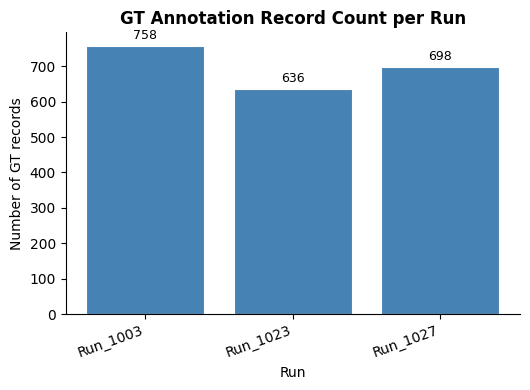

In [20]:
# ── F1. Bar chart: GT record count per run ─────────────────────────────────
run_names_plot = []
gt_counts      = []

for run in selected_runs:
    info = gt_data.get(run.name)
    if info and 'df' in info:
        run_names_plot.append(run.name)
        gt_counts.append(len(info['df']))

if gt_counts:
    fig, ax = plt.subplots(figsize=(max(5, len(run_names_plot) * 1.8), 4))
    bars = ax.bar(run_names_plot, gt_counts, color='steelblue', edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
    ax.set_title('GT Annotation Record Count per Run', fontsize=12, fontweight='bold')
    ax.set_xlabel('Run')
    ax.set_ylabel('Number of GT records')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.spines[['top', 'right']].set_visible(False)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No GT data available for bar chart.')

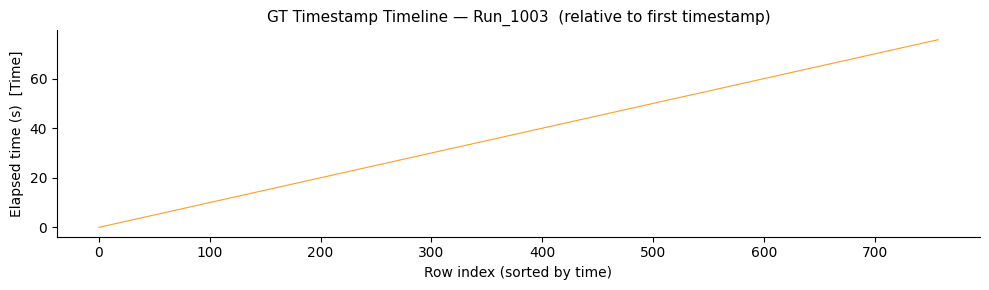

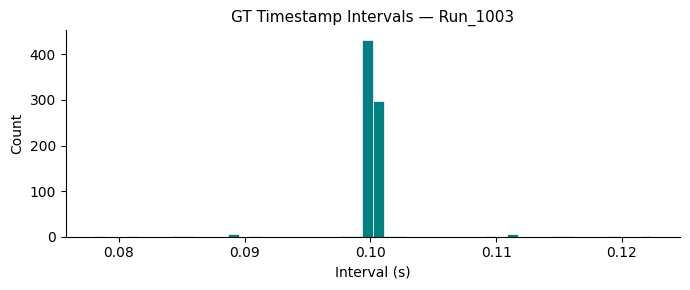

In [21]:
# ── F2. Timeline plot: GT timestamps vs row index for the first available run
timeline_run = None
for run in selected_runs:
    info = gt_data.get(run.name)
    if info and 'ts_series' in info:
        timeline_run = run
        break

if timeline_run is not None:
    info   = gt_data[timeline_run.name]
    ts     = info['ts_series'].sort_values().reset_index(drop=True)
    ts_col = info['ts_col']

    # Normalise to seconds from start for readability
    ts_norm = ts - ts.iloc[0]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(ts_norm.index, ts_norm.values, color='darkorange', linewidth=0.8, alpha=0.85)
    ax.set_title(f'GT Timestamp Timeline — {timeline_run.name}  (relative to first timestamp)', fontsize=11)
    ax.set_xlabel('Row index (sorted by time)')
    ax.set_ylabel(f'Elapsed time (s)  [{ts_col}]')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

    # Also plot histogram of inter-frame intervals
    diffs = ts.diff().dropna()
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(diffs, bins=50, color='teal', edgecolor='white', linewidth=0.5)
    ax.set_title(f'GT Timestamp Intervals — {timeline_run.name}', fontsize=11)
    ax.set_xlabel('Interval (s)')
    ax.set_ylabel('Count')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print('No GT timestamp series available for timeline plot.')

---
## Summary

| Step | What it does |
|------|--------------|
| **0-1** | `wget` download of the zip directly into Colab `/content/` (no Drive needed) |
| **0-2** | Peek inside zip — list all entries, top-level structure, without extracting |
| **0-3** | Auto-detect the `validation/` prefix inside the zip |
| **0-4** | Selective extraction — skip `.pcap` / video; extract only CSVs, JSONs, annotations (~MB not GB) |
| **0-5** | Auto-derive `DATA_ROOT` from extracted path |
| **A**   | Run folder discovery, tree structure (depth 2) |
| **B**   | File type categorisation per run |
| **C**   | GT columns, object types/IDs, timestamps · Timing file freq · Signal phases · Conflict labels |
| **D**   | GT ↔ timing timestamp overlap and sampling rate |
| **E**   | Missing files, empty files, GT schema consistency |
| **F**   | GT record count bar chart, timestamp timeline + interval histogram |